# VinBigData annotációk feltáró elemzése (EDA)

A `train.csv` annotációk vizsgálata:
- Radiológusok közötti egyezés
- Finding-ek közötti korreláció
- Bbox méret eloszlások
- Képenkénti annotáció sűrűség

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

df = pd.read_csv('../datas/train.csv')
print('Shape:', df.shape)
df.head()

Shape: (67914, 8)


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [4]:
TARGET_FINDINGS = [
    'Aortic enlargement', 'Cardiomegaly', 'Pleural thickening',
    'Pulmonary fibrosis', 'Lung Opacity'
]
ALL_FINDINGS = [c for c in df['class_name'].unique() if c != 'No finding']

## 1. Radiológusok közötti egyezés

In [5]:
# Képszintű finding mátrix radiológusonként
rad_ids = sorted(df['rad_id'].unique())
print(f'Radiológusok száma: {len(rad_ids)}')
print(f'Radiológus ID-k: {rad_ids}')
print(f'Annotációk radiológusonként:')
print(df.groupby('rad_id')['image_id'].nunique())

Radiológusok száma: 17
Radiológus ID-k: ['R1', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15', 'R16', 'R17', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9']
Annotációk radiológusonként:
rad_id
R1     1995
R10    6467
R11    1526
R12    1671
R13    1629
R14    1440
R15    1639
R16    1676
R17     776
R2     3119
R3     2285
R4     1513
R5     2783
R6     2041
R7     1733
R8     6582
R9     6125
Name: image_id, dtype: int64


In [6]:
# Radiológusonként képszintű label mátrix
def build_image_labels(df, rad_id, findings):
    rad_df = df[df['rad_id'] == rad_id]
    image_ids = df['image_id'].unique()
    labels = pd.DataFrame({'image_id': image_ids})
    for f in findings:
        marked = rad_df[rad_df['class_name'] == f]['image_id'].unique()
        labels[f] = labels['image_id'].isin(marked).astype(int)
    return labels.set_index('image_id')

rad_labels = {r: build_image_labels(df, r, TARGET_FINDINGS) for r in rad_ids}

In [7]:
# Egyezési arány (agreement rate) radiológus-páronként és finding-enként
from sklearn.metrics import cohen_kappa_score

pairs = list(combinations(rad_ids, 2))

agreement_data = []
for r1, r2 in pairs:
    for f in TARGET_FINDINGS:
        kappa = cohen_kappa_score(rad_labels[r1][f], rad_labels[r2][f])
        agree_pct = (rad_labels[r1][f] == rad_labels[r2][f]).mean() * 100
        agreement_data.append({
            'pair': f'R{r1}-R{r2}',
            'finding': f,
            'kappa': kappa,
            'agreement_%': agree_pct
        })

agreement_df = pd.DataFrame(agreement_data)
agreement_df

C:\Users\Lenovo\PycharmProjects\halado-adatelemzes-orvosi-kepfeldolgozas\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
C:\Users\Lenovo\PycharmProjects\halado-adatelemzes-orvosi-kepfeldolgozas\.venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)
C:\Users\Lenovo\PycharmProjects\halado-adatelemzes-orvosi-kepfeldolgozas\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
C:\Users\Lenovo\PycharmProjects\halado-adatelemzes-orvosi-kepfeldolgozas\.venv\Lib\site-packages\sk

,pair,finding,kappa,agreement_%
0,RR1-RR10,Aortic enlargement,0.000000,84.340000
1,RR1-RR10,Cardiomegaly,0.000000,87.773333
2,RR1-RR10,Pleural thickening,0.000000,94.513333
3,RR1-RR10,Pulmonary fibrosis,0.000000,93.526667
4,RR1-RR10,Lung Opacity,0.000000,95.033333
...,...,...,...,...
675,RR8-RR9,Aortic enlargement,0.782249,94.333333
676,RR8-RR9,Cardiomegaly,0.784687,95.646667
677,RR8-RR9,Pleural thickening,0.439027,91.900000
678,RR8-RR9,Pulmonary fibrosis,0.681568,95.726667




In [8]:
# Cohen's Kappa heatmap radiológus-páronként
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 5))
if len(pairs) == 1:
    axes = [axes]

for ax, (r1, r2) in zip(axes, pairs):
    pair_df = agreement_df[agreement_df['pair'] == f'R{r1}-R{r2}']
    kappas = pair_df.set_index('finding')['kappa']
    sns.barplot(x=kappas.values, y=kappas.index, ax=ax, orient='h')
    ax.set_title(f'R{r1} vs R{r2}')
    ax.set_xlabel('Cohen\'s Kappa')
    ax.set_xlim(-0.1, 1.0)
    for i, v in enumerate(kappas.values):
        ax.text(v + 0.02, i, f'{v:.2f}', va='center')

plt.suptitle('Radiológusok közötti egyezés (Cohen\'s Kappa)', y=1.02)
plt.tight_layout()
plt.show()

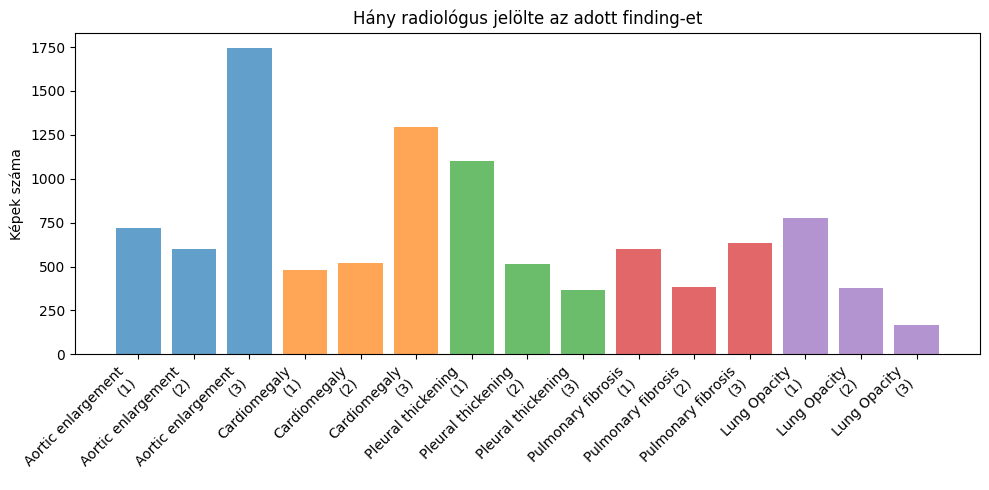

In [9]:
# Hány radiológus jelölte az adott finding-et képenként
annotator_counts = []
for f in TARGET_FINDINGS:
    f_df = df[df['class_name'] == f]
    counts = f_df.groupby('image_id')['rad_id'].nunique()
    for n_rads, cnt in counts.value_counts().sort_index().items():
        annotator_counts.append({'finding': f, 'annotators': n_rads, 'images': cnt})

ac_df = pd.DataFrame(annotator_counts)
fig, ax = plt.subplots(figsize=(10, 5))
for f in TARGET_FINDINGS:
    sub = ac_df[ac_df['finding'] == f]
    ax.bar([f'{f}\n({n})' for n in sub['annotators']], sub['images'], label=f, alpha=0.7)

ax.set_ylabel('Képek száma')
ax.set_title('Hány radiológus jelölte az adott finding-et')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Finding-ek közötti korreláció

In [10]:
# Képszintű aggregálás: finding jelen van-e (bármely radiológus szerint)
image_labels = pd.DataFrame({'image_id': df['image_id'].unique()})
for f in ALL_FINDINGS:
    marked = df[df['class_name'] == f]['image_id'].unique()
    image_labels[f] = image_labels['image_id'].isin(marked).astype(int)

image_labels = image_labels.set_index('image_id')
print(f'Képek száma: {len(image_labels)}')
print(f'\nFinding prevalencia:')
print(image_labels.sum().sort_values(ascending=False))

Képek száma: 15000

Finding prevalencia:
Aortic enlargement    3067
Cardiomegaly          2300
Pleural thickening    1981
Pulmonary fibrosis    1617
Lung Opacity          1322
Other lesion          1134
Pleural effusion      1032
Nodule/Mass            826
Infiltration           613
Calcification          452
ILD                    386
Consolidation          353
Atelectasis            186
Pneumothorax            96
dtype: int64


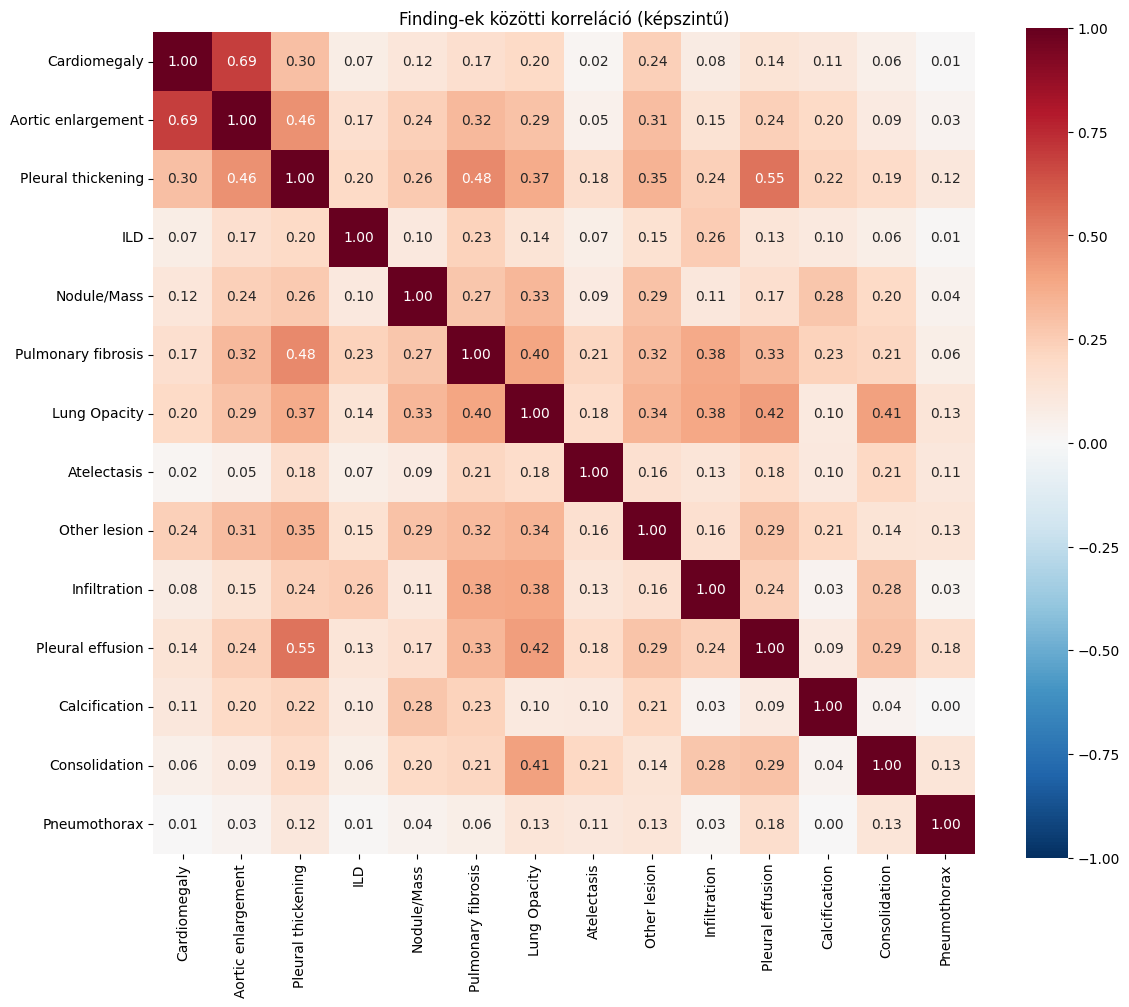

In [11]:
# Korreláció heatmap az összes finding között
corr = image_labels.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Finding-ek közötti korreláció (képszintű)')
plt.tight_layout()
plt.show()

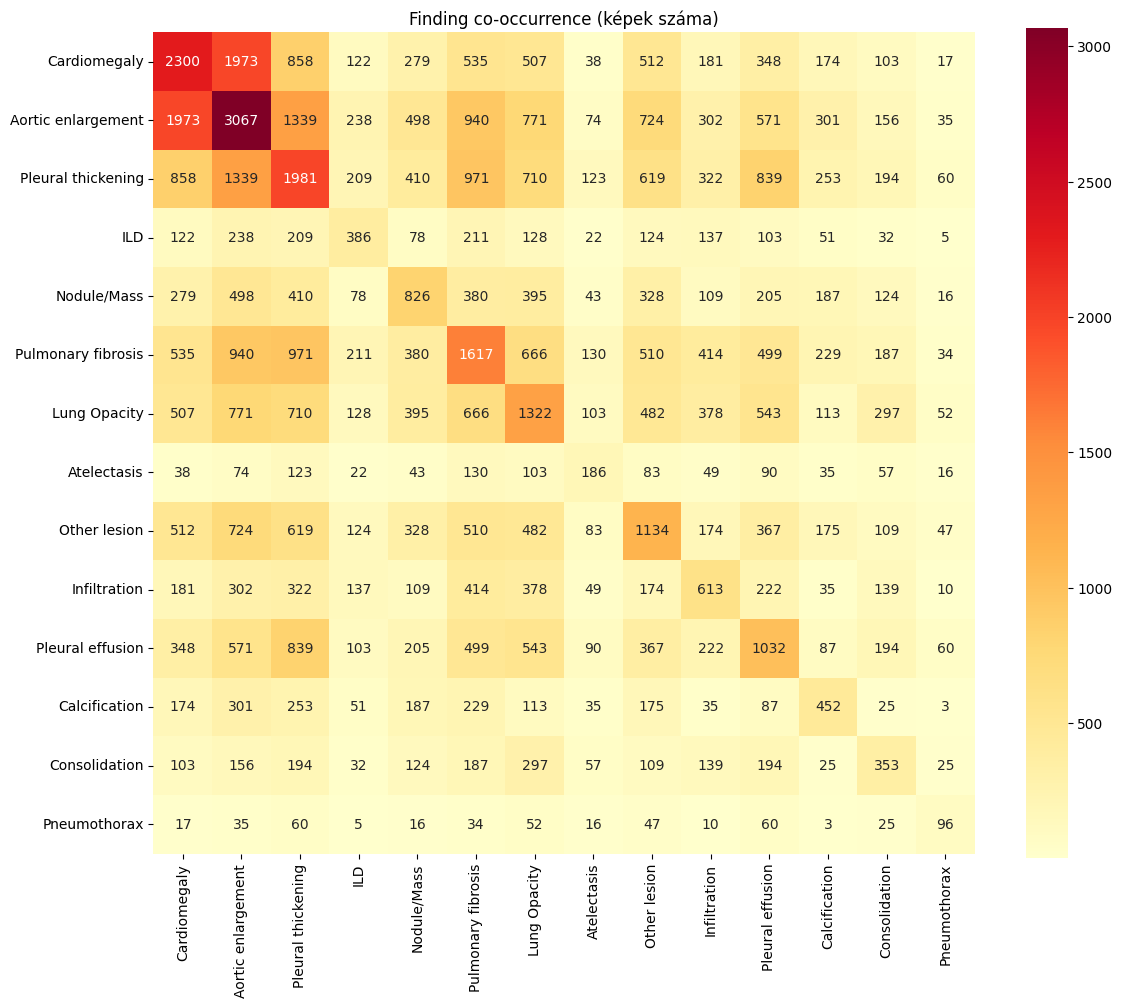

In [12]:
# Co-occurrence mátrix: hány képen jelennek meg együtt
cooc = image_labels.T.dot(image_labels)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cooc, annot=True, fmt='d', cmap='YlOrRd', ax=ax, square=True)
ax.set_title('Finding co-occurrence (képek száma)')
plt.tight_layout()
plt.show()

## 3. Bbox méret eloszlások

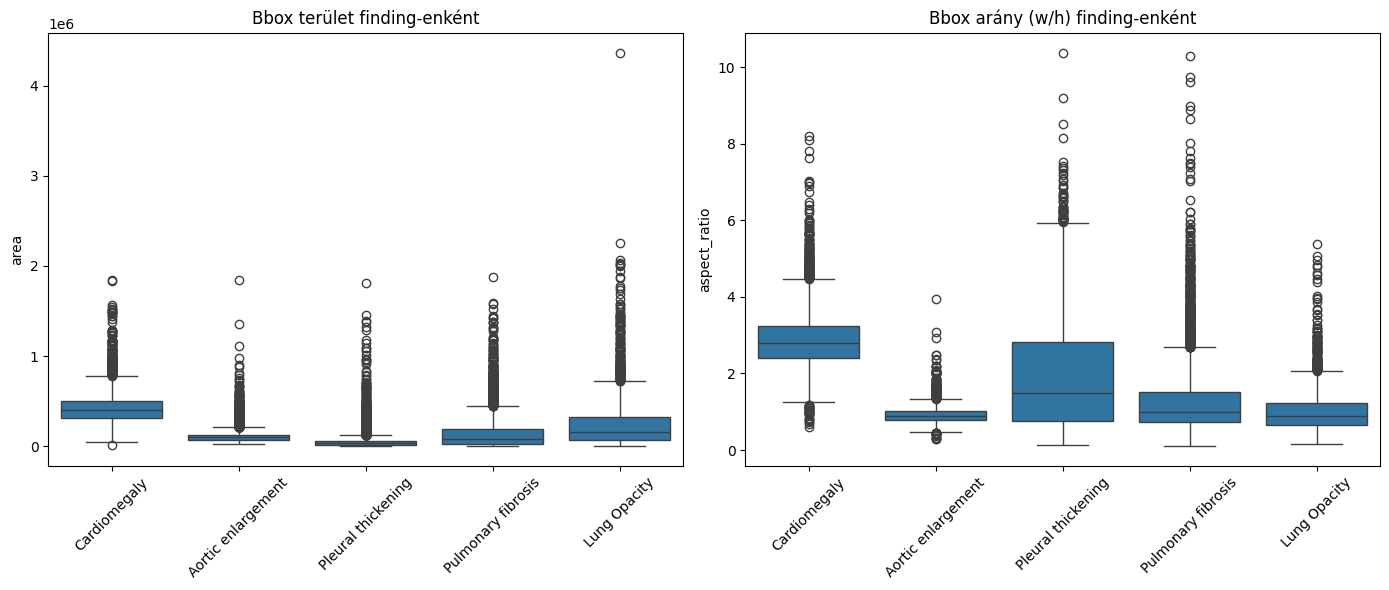

In [13]:
# Bbox terület és arány finding-enként
bbox_df = df[df['class_name'] != 'No finding'].copy()
bbox_df['width'] = bbox_df['x_max'] - bbox_df['x_min']
bbox_df['height'] = bbox_df['y_max'] - bbox_df['y_min']
bbox_df['area'] = bbox_df['width'] * bbox_df['height']
bbox_df['aspect_ratio'] = bbox_df['width'] / bbox_df['height']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

target_bbox = bbox_df[bbox_df['class_name'].isin(TARGET_FINDINGS)]

sns.boxplot(data=target_bbox, x='class_name', y='area', ax=axes[0])
axes[0].set_title('Bbox terület finding-enként')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=target_bbox, x='class_name', y='aspect_ratio', ax=axes[1])
axes[1].set_title('Bbox arány (w/h) finding-enként')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

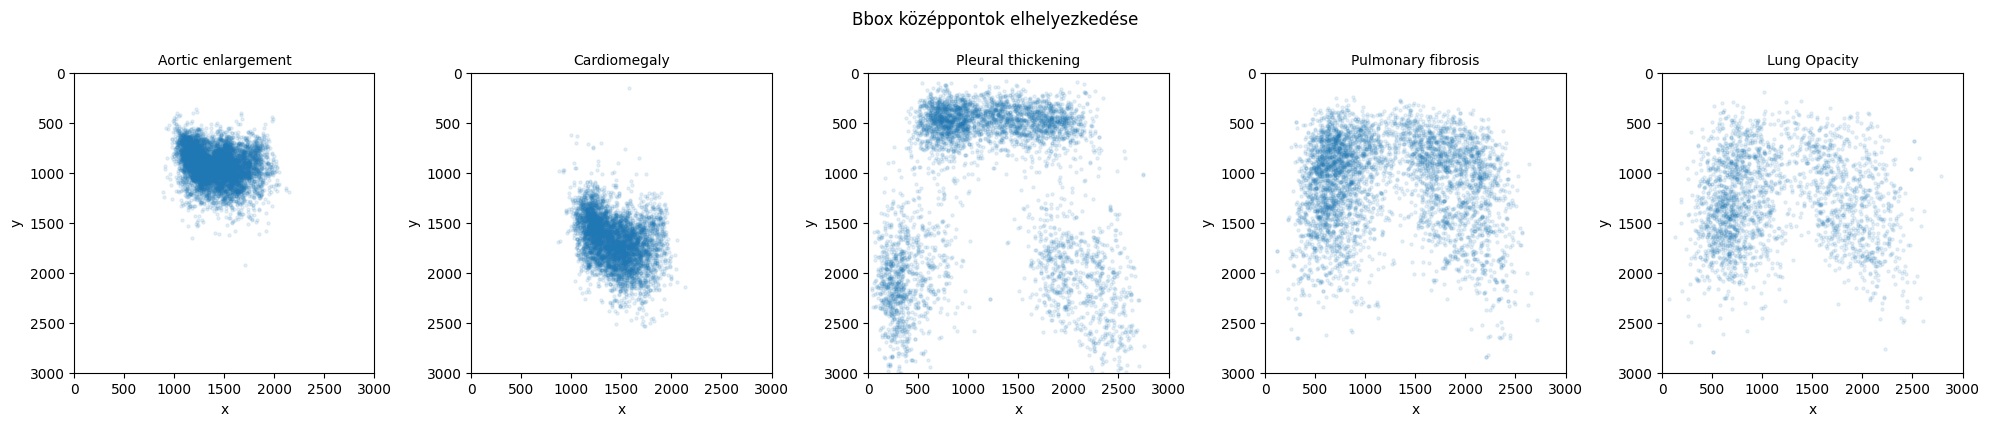

In [14]:
# Bbox pozíció scatter (középpont) finding-enként
target_bbox = target_bbox.copy()
target_bbox['cx'] = (target_bbox['x_min'] + target_bbox['x_max']) / 2
target_bbox['cy'] = (target_bbox['y_min'] + target_bbox['y_max']) / 2

fig, axes = plt.subplots(1, len(TARGET_FINDINGS), figsize=(4 * len(TARGET_FINDINGS), 4))
for ax, f in zip(axes, TARGET_FINDINGS):
    sub = target_bbox[target_bbox['class_name'] == f]
    ax.scatter(sub['cx'], sub['cy'], alpha=0.1, s=5)
    ax.set_title(f, fontsize=10)
    ax.set_xlim(0, 3000)
    ax.set_ylim(3000, 0)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Bbox középpontok elhelyezkedése', y=1.02)
plt.tight_layout()
plt.show()

## 4. Képenkénti annotáció sűrűség

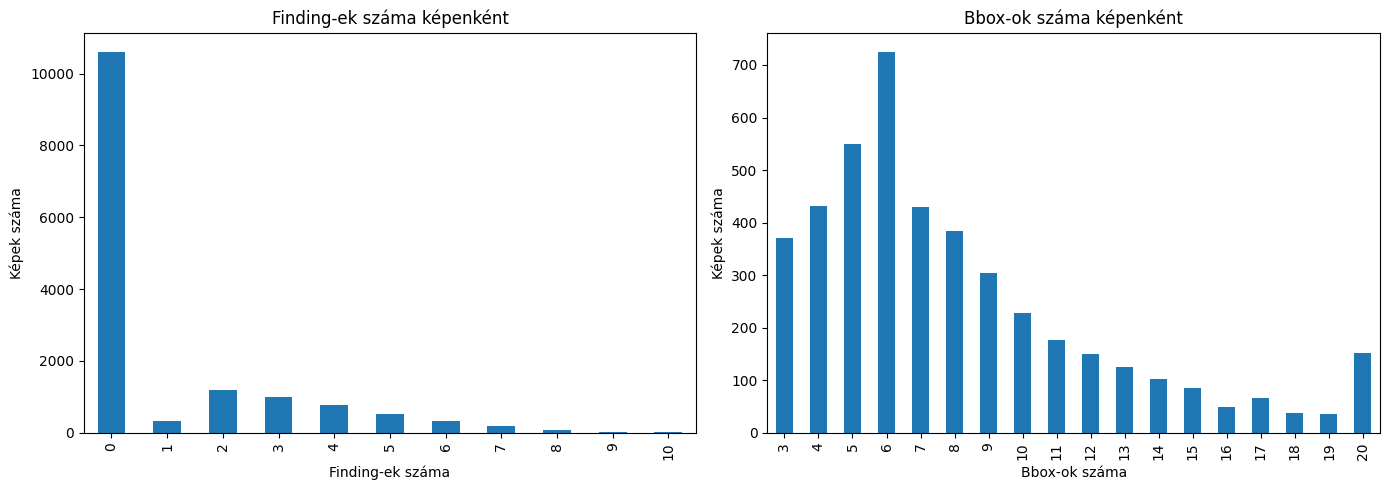

Átlag finding/kép: 1.02
Átlag bbox/kép (annotált képekre): 8.21


In [15]:
# Finding-ek száma képenként
findings_per_image = image_labels.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

findings_per_image.value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Finding-ek száma képenként')
axes[0].set_xlabel('Finding-ek száma')
axes[0].set_ylabel('Képek száma')

# Bbox-ok száma képenként
bbox_counts = bbox_df.groupby('image_id').size()
bbox_counts.clip(upper=20).value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Bbox-ok száma képenként')
axes[1].set_xlabel('Bbox-ok száma')
axes[1].set_ylabel('Képek száma')

plt.tight_layout()
plt.show()

print(f'Átlag finding/kép: {findings_per_image.mean():.2f}')
print(f'Átlag bbox/kép (annotált képekre): {bbox_counts.mean():.2f}')

In [16]:
# Összesítő statisztikák
total_images = df['image_id'].nunique()
no_finding = (findings_per_image == 0).sum()

print(f'Összesen képek: {total_images}')
print(f'No finding (mind 0): {no_finding} ({no_finding/total_images*100:.1f}%)')
print(f'Legalább 1 finding: {total_images - no_finding} ({(total_images-no_finding)/total_images*100:.1f}%)')
print(f'\nTarget finding prevalencia:')
for f in TARGET_FINDINGS:
    n = image_labels[f].sum()
    print(f'  {f}: {n} ({n/total_images*100:.1f}%)')

Összesen képek: 15000
No finding (mind 0): 10606 (70.7%)
Legalább 1 finding: 4394 (29.3%)

Target finding prevalencia:
  Aortic enlargement: 3067 (20.4%)
  Cardiomegaly: 2300 (15.3%)
  Pleural thickening: 1981 (13.2%)
  Pulmonary fibrosis: 1617 (10.8%)
  Lung Opacity: 1322 (8.8%)
